## Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score)

# Suppress warnings that fire when a test window contains no fraud cases.
# This can happen in freeze/recurring datasets; affected metrics return NaN.
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
warnings.filterwarnings('ignore', message='No positive class found in y_true')

# Fix random seeds for reproducibility across all libraries.
SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


## Configuration

In [2]:
# --- EXPERIMENT CONFIGURATION ---
N_FEATURES = 9              # 9 input features
N_TASKS    = 10             # 10 time periods
N_EPOCHS   = 20             # Number of epochs
LEARNING_RATE = 0.01        # Learning rate
MEMORY_SIZE   = 100000      # Size of the replay buffer
EWC_LAMBDA    = 5000        # EWC penalty strength
PACKNET_PRUNE_RATIO = 0.3   # Fraction of free weights pruned after each task
FISHER_SAMPLES = 500        # Samples used to estimate Fisher Information (EWC)
SI_LAMBDA     = 1000        # Penalty strength for Synaptic Intelligence
DER_ALPHA     = 0.5         # Weight on dark-knowledge distillation loss (DER)
DER_BETA      = 0.5         # Weight on hard-label replay loss (DER++)

# Methods to run
RUN_METHODS = {
    "naive":       True,
    "replay":      True,
    "ewc":         True,
    "packnet":     True,
    "full_replay": True,
    "si":          True,
    "der":         True,
}

# Dataset directory (relative to the notebook location)
BASE_DIR = Path("Thesis Datasets Final")
# Axis mapping:
#   0 = Baseline (1 dataset)
#   1 = Drift Magnitude (16 datasets)
#   2 = Drift Speed (8 datasets)
#   3 = Freeze Duration (6 datasets)
#   4 = Freeze Depth (6 datasets)
#   5 = Pattern Rotation (7 datasets)
# RUN_AXES = None        # run all 44 datasets
RUN_AXES = [0,1,2,3,4,5]

# Which metrics to include in the output?
SHOW_METRICS = {
    "AvgPR":     True,
    "ForgetPR":  True,
    "AvgAcc":    True,
    "ForgetAcc": True,
}


## Model

In [3]:
# --- MODEL ARCHITECTURE ---
# Fixed 3-layer MLP used across all experiments.
# Architecture is kept constant so that performance differences reflect the CL method,
# not the model. BatchNorm stabilizes training under covariate drift; Dropout
# reduces overfitting under class imbalance. The output is a raw logit (no Sigmoid),
# which BCEWithLogitsLoss handles internally during training.

class FraudDetector(nn.Module):
    def __init__(self, input_features=N_FEATURES, dropout=0.3):
        super(FraudDetector, self).__init__()

        self.layer1   = nn.Linear(input_features, 64)
        self.bn1      = nn.BatchNorm1d(64)
        self.dropout1 = nn.Dropout(dropout)

        self.layer2   = nn.Linear(64, 32)
        self.bn2      = nn.BatchNorm1d(32)
        self.dropout2 = nn.Dropout(dropout)

        # Single shared output head: Domain-IL setup, label space never changes
        # and no task ID is passed at inference time.
        self.output_layer = nn.Linear(32, 1)
        self.relu         = nn.ReLU()

    def forward(self, x):
        x = self.dropout1(self.relu(self.bn1(self.layer1(x))))
        x = self.dropout2(self.relu(self.bn2(self.layer2(x))))
        x = self.output_layer(x)
        return x

print("FraudDetector ready (3-layer MLP, BatchNorm + Dropout, logits output).")


FraudDetector ready (3-layer MLP, BatchNorm + Dropout, logits output).


## Data Loader

In [4]:
# --- REAL DATASET LOADER ---
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

FEATURE_COLS = [
    "time_hour", "amount", "is_remote",
    "velocity_1h", "velocity_24h",
    "delta_amount", "amount_zscore",
    "is_new_country", "hours_since_last"
]

_df_global  = None
_scaler     = None
_data_cache = {}

def _load_dataset():
    global _df_global
    if _df_global is not None:
        return
    print("Loading dataset...")
    _df_global = pd.read_csv(DATA_PATH)
    print(f"Loaded {len(_df_global):,} rows | fraud rate: {_df_global['is_fraud'].mean()*100:.3f}%")

def get_data_for_task(task_id, split="train"):
    """
    Loads one period (task) from the current dataset and returns train/test tensors.

    IMPORTANT ROBUSTNESS FIX:
    - Some drift datasets (freeze/recurring) can contain periods with 0 or 1 fraud sample.
    - Stratified splitting requires at least 2 samples in EACH class.
    - Therefore, we stratify only when it is valid; otherwise we fall back to a normal split.
    """
    global _scaler, _data_cache

    if (task_id, split) in _data_cache:
        return _data_cache[(task_id, split)]

    _load_dataset()

    period = task_id + 1  # periods in CSV are 1-based
    period_df = _df_global[_df_global["period"] == period].copy()

    # Safety check: if a period is empty, fail early with a clear message
    if len(period_df) == 0:
        raise ValueError(f"Period/task {period} is empty in the dataset. Check your period construction.")

    X_all = period_df[FEATURE_COLS].values.astype("float32")
    y_all = period_df["is_fraud"].values.astype("float32")

    # --- SAFE STRATIFY LOGIC ---
    n_pos = int((y_all == 1).sum())
    n_neg = int((y_all == 0).sum())
    use_stratify = (n_pos >= 6) and (n_neg >= 2)

    if not use_stratify:
        print(f"   [Split Warning] Task {task_id}: stratify disabled (n_pos={n_pos} < 6 required)")

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_all,
        y_all,
        test_size=0.2,
        random_state=42,
        stratify=y_all if use_stratify else None
    )

    # --- SMOTE OVERSAMPLING (training data only) ---
    # Applied after train/test split and before scaling to prevent data leakage.
    # Requires at least k_neighbors+1 minority samples to function correctly.
    n_pos_train = int((y_train == 1).sum())
    if n_pos_train < 6:
        print(f"   [SMOTE Warning] Task {task_id}: skipping SMOTE (n_pos={n_pos_train} < 6 required)")
    else:
        smote = SMOTE(random_state=42, k_neighbors=5, sampling_strategy='auto')
        X_train_raw, y_train = smote.fit_resample(X_train_raw, y_train)

    # Fit scaler once on the first training chunk (consistent across tasks)
    if _scaler is None:
        _scaler = StandardScaler().fit(X_train_raw)

    X_train = _scaler.transform(X_train_raw)
    X_test  = _scaler.transform(X_test_raw)

    _data_cache[(task_id, "train")] = (torch.FloatTensor(X_train), torch.FloatTensor(y_train).unsqueeze(1))
    _data_cache[(task_id, "test")]  = (torch.FloatTensor(X_test),  torch.FloatTensor(y_test).unsqueeze(1))
    return _data_cache[(task_id, split)]

print("Data loader ready.")

Data loader ready.


## Metrics

In [5]:
def compute_thesis_metrics(acc_mat, pr_mat):
    """
    Compute standard thesis metrics from evaluation matrices.

    IMPORTANT ROBUSTNESS FIX:
    - In freeze/recurring drift, some tasks may have 0 (or very few) fraud cases in the test split.
    - In that case PR-AUC is undefined and may be NaN.
    - We therefore use NaN-safe aggregation for PR metrics.
    """
    n_tasks = acc_mat.shape[0]

    # Average performance after training on all tasks
    avg_acc = float(np.mean(acc_mat[n_tasks - 1]))
    avg_pr  = float(np.nanmean(pr_mat[n_tasks - 1]))  # ignore NaNs

    # Forgetting / backward transfer-style metric on accuracy (always defined)
    forgetting_acc = 0.0
    for t in range(n_tasks - 1):
        forgetting_acc += acc_mat[n_tasks - 1, t] - acc_mat[t, t]
    avg_forgetting_acc = float(forgetting_acc / (n_tasks - 1))

    # Forgetting on PR-AUC (skip undefined comparisons)
    pr_diffs = []
    for t in range(n_tasks - 1):
        final_val = pr_mat[n_tasks - 1, t]
        diag_val  = pr_mat[t, t]
        if not (np.isnan(final_val) or np.isnan(diag_val)):
            pr_diffs.append(final_val - diag_val)

    avg_forgetting_pr = float(np.mean(pr_diffs)) if len(pr_diffs) > 0 else float("nan")

    return avg_acc, avg_forgetting_acc, avg_pr, avg_forgetting_pr

## Training Functions

In [6]:
# Trains the model on one task (one time period) using Adam + BCEWithLogitsLoss.
# BCEWithLogitsLoss applies Sigmoid internally for numerical stability.
# Used directly by the Naive method; other methods extend this logic.

def train_on_task(model, X_train, y_train, epochs=N_EPOCHS, lr=LEARNING_RATE):
    """
    Args:
        model:   Neural network to train.
        X_train: torch.Tensor (N, N_FEATURES) -- transaction features.
        y_train: torch.Tensor (N, 1)          -- fraud labels (0 or 1).
        epochs:  Training epochs.
        lr:      Learning rate for Adam.

    Returns:
        model: The trained model (updated in place).
    """
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        logits = model(X_train)
        loss   = criterion(logits, y_train)
        loss.backward()
        optimizer.step()

    model.eval()
    return model

print("train_on_task() ready.")


train_on_task() ready.


In [7]:
# Trains on a mix of current-task data and a fixed-size buffer of past transactions.
# On the first task the buffer is empty and training proceeds on new data only.
# Buffer management (sampling and trimming to MEMORY_SIZE) is handled in the runner.

def train_with_replay(model, X_new, y_new, buffer_X, buffer_y,
                      epochs=N_EPOCHS, lr=LEARNING_RATE):
    """
    Args:
        model:              Neural network to train.
        X_new, y_new:       Current task data.
        buffer_X, buffer_y: Stored samples from previous tasks (empty on task 0).
        epochs:             Training epochs.
        lr:                 Learning rate for Adam.

    Returns:
        model: Updated model trained on current + replay data.
    """
    if buffer_X.numel() > 0:
        X_combined = torch.cat((X_new, buffer_X), dim=0)
        y_combined = torch.cat((y_new, buffer_y), dim=0)
    else:
        X_combined = X_new
        y_combined = y_new

    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        logits = model(X_combined)
        loss   = criterion(logits, y_combined)
        loss.backward()
        optimizer.step()

    model.eval()
    return model

print("train_with_replay() ready.")


train_with_replay() ready.


In [8]:
# --- EWC (Elastic Weight Consolidation) ---
# Estimates weight importance via the diagonal Fisher Information after each task.
# Weights with high Fisher values are penalised more heavily if they drift in future tasks.
#
# Stored per task:
#   params  -- weight snapshot after training (theta*)
#   fisher  -- estimated importance (mean squared gradients over a random subset)
#
# Penalty during future training:
#   penalty = sum Fisher_i * (current_weight_i - theta*_i)^2

class EWC:
    def __init__(self, model, dataset):
        """
        Args:
            model:   Neural network already trained on the current task.
            dataset: Tuple (X, y) used to estimate Fisher importance.
        """
        self.model   = model
        self.dataset = dataset
        self.params  = {}
        self.fisher  = {}
        self._compute_fisher()

    def _compute_fisher(self):
        for name, param in self.model.named_parameters():
            self.params[name] = param.data.clone()
            self.fisher[name] = torch.zeros_like(param.data)

        self.model.eval()
        criterion = nn.BCEWithLogitsLoss()
        X_data, y_data = self.dataset

        # Use a random subset for Fisher estimation (standard EWC practice).
        # FISHER_SAMPLES gives a good approximation while keeping runtime manageable.
        n_samples = min(FISHER_SAMPLES, len(X_data))
        idx = torch.randperm(len(X_data))[:n_samples]
        X_sub, y_sub = X_data[idx], y_data[idx]

        for i in range(n_samples):
            self.model.zero_grad()
            logits = self.model(X_sub[i].unsqueeze(0))
            loss   = criterion(logits, y_sub[i].unsqueeze(0))
            loss.backward()
            for name, param in self.model.named_parameters():
                if param.grad is not None:
                    self.fisher[name] += param.grad.data.pow(2)

        for name in self.fisher:
            self.fisher[name] /= n_samples

    def penalty(self, model):
        """Importance-weighted penalty discouraging drift from the stored weight snapshot."""
        loss = 0.0
        for name, param in model.named_parameters():
            loss += (self.fisher[name] * (param - self.params[name]).pow(2)).sum()
        return loss

print("EWC class ready.")


EWC class ready.


In [9]:
# Trains on the current task while adding an EWC penalty to protect weights
# that were important for previous tasks.
#
#   total_loss = task_loss + lambda * sum(EWC_penalty per past task)
#
# All past tasks are penalised simultaneously. On the first task ewc_list is
# empty so no penalty is applied.

def train_with_ewc(model, X_train, y_train, ewc_list,
                   importance_factor=EWC_LAMBDA, epochs=N_EPOCHS, lr=LEARNING_RATE):
    """
    Args:
        model:             Neural network to train.
        X_train, y_train:  Current task data.
        ewc_list:          List of EWC objects from all previous tasks.
        importance_factor: Lambda -- penalty strength.
        epochs:            Training epochs.
        lr:                Learning rate.

    Returns:
        model: Updated model.
    """
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        logits    = model(X_train)
        task_loss = criterion(logits, y_train)

        ewc_loss = 0.0
        if ewc_list:
            ewc_loss = sum(ewc.penalty(model) for ewc in ewc_list)

        loss = task_loss + (importance_factor * ewc_loss)
        loss.backward()
        optimizer.step()

    model.eval()
    return model

print("train_with_ewc() ready.")


train_with_ewc() ready.


In [10]:
# --- PACKNET HELPER FUNCTIONS ---
# Three functions that implement PackNet's parameter isolation:
#
#   1) init_frozen_mask()              -- initialise mask with all weights free
#   2) apply_pruning_and_update_mask() -- prune + freeze after each task
#   3) report_mask_capacity()          -- print remaining free capacity
#
# After each task, the lowest-magnitude free weights are pruned (zeroed) and the
# remaining free weights are frozen. Each task owns a private, non-overlapping
# subset of parameters, preventing cross-task interference.
#
# PackNet operates in the Task-IL setting; other methods use Domain-IL.

def init_frozen_mask(model):
    """All weights start as FREE (False = not frozen)."""
    return {name: torch.zeros_like(param.data, dtype=torch.bool)
            for name, param in model.named_parameters()}


def apply_pruning_and_update_mask(model, frozen_mask, prune_ratio=PACKNET_PRUNE_RATIO):
    """
    Post-task step: zero the lowest-magnitude free weights, then freeze the rest.

    Args:
        model:       Trained model after the current task.
        frozen_mask: Current mask (updated in place).
        prune_ratio: Fraction of free weights to prune.

    Returns:
        updated frozen_mask
    """
    for name, param in model.named_parameters():
        w         = param.data
        free_mask = ~frozen_mask[name]

        if free_mask.sum().item() == 0:
            continue

        free_weights_abs = w[free_mask].abs()
        n_free  = free_weights_abs.numel()
        n_prune = int(prune_ratio * n_free)

        if n_prune <= 0:
            frozen_mask[name][free_mask] = True
            continue

        threshold = torch.kthvalue(free_weights_abs, k=min(n_prune, n_free)).values.item()
        w[free_mask & (w.abs() <= threshold)] = 0.0
        frozen_mask[name][free_mask & (w != 0.0)] = True

    return frozen_mask


def report_mask_capacity(model, frozen_mask):
    """Print a capacity report: frozen vs free parameters."""
    total = frozen = free_nz = free_z = 0
    for name, param in model.named_parameters():
        w, fm = param.data, frozen_mask[name]
        free_mask = ~fm
        total   += w.numel()
        frozen  += fm.sum().item()
        free_nz += (free_mask & (w != 0.0)).sum().item()
        free_z  += (free_mask & (w == 0.0)).sum().item()
    free = total - frozen
    print(f"  [Capacity] Total={total} | Frozen={frozen} ({frozen/total:.0%}) | "
          f"Free={free} ({free/total:.0%}) [non-zero={free_nz}, zero={free_z}]")

print("PackNet helper functions ready.")


PackNet helper functions ready.


In [11]:
# Identical to train_on_task() with one addition: gradients for frozen parameters
# are zeroed before the optimizer step so only free weights are updated.

def train_with_packnet(model, X_train, y_train, frozen_mask,
                       epochs=N_EPOCHS, lr=LEARNING_RATE):
    """
    Args:
        model:       Neural network to train.
        X_train:     Current task features.
        y_train:     Current task fraud labels.
        frozen_mask: Dict of boolean tensors -- True = frozen, False = free.
        epochs:      Training epochs.
        lr:          Learning rate.

    Returns:
        model: Updated model with only free parameters changed.
    """
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        logits = model(X_train)
        loss   = criterion(logits, y_train)
        loss.backward()

        # Zero out gradients for frozen weights so the optimizer cannot update them.
        for name, param in model.named_parameters():
            if param.grad is not None:
                param.grad[frozen_mask[name]] = 0.0

        optimizer.step()

    model.eval()
    return model

print("train_with_packnet() ready.")


train_with_packnet() ready.


In [12]:
# --- SYNAPTIC INTELLIGENCE (SI) ---
# Regularization-based CL method similar to EWC, but importance is accumulated
# online DURING training rather than computed post-hoc.
#
# Per optimizer step:
#   omega_i += -grad_i * delta_theta_i
#   (how much did this weight contribute to reducing the loss?)
#
# After each task (normalized importance update):
#   Omega_i += omega_i / (delta_theta_i_total^2 + eps)
#
# Penalty during future training:
#   L_SI = c * sum Omega_i * (theta_i - theta*_i)^2

class SynapticIntelligence:
    def __init__(self):
        self.omega      = {}  # global importance per weight (cumulative across tasks)
        self.theta_star = {}  # weight snapshot after the most recent task

    def register_task(self, model, small_omega, prev_params):
        """
        Update global importance and store weight snapshot after a completed task.

        Args:
            model:        The model after training on the completed task.
            small_omega:  Per-weight path integral omega accumulated during training.
            prev_params:  Weight snapshots at the start of the task.
        """
        for name, param in model.named_parameters():
            delta           = param.data - prev_params[name]
            task_importance = small_omega[name] / (delta ** 2 + 1e-3)

            if name not in self.omega:
                self.omega[name] = torch.zeros_like(param.data)
            self.omega[name]    = torch.clamp(self.omega[name] + task_importance, min=0.0)
            self.theta_star[name] = param.data.clone()

    def penalty(self, model):
        """SI regularisation penalty. Returns 0 before any task is registered."""
        loss = torch.tensor(0.0)
        for name, param in model.named_parameters():
            if name in self.omega:
                loss = loss + (self.omega[name] * (param - self.theta_star[name]) ** 2).sum()
        return loss

print("SynapticIntelligence class ready.")


SynapticIntelligence class ready.


In [13]:
# Trains on the current task with an SI regularisation penalty, while accumulating
# the per-step path integral omega for use in register_task() afterwards.
#
#   total_loss = task_loss + c * SI_penalty
#
# Per optimizer step: omega_i += -grad_i * delta_theta_i

def train_with_si(model, X_train, y_train, si,
                  importance_factor=SI_LAMBDA, epochs=N_EPOCHS, lr=LEARNING_RATE):
    """
    Args:
        model:             Neural network to train.
        X_train, y_train:  Current task data (torch tensors).
        si:                SynapticIntelligence object.
        importance_factor: Lambda -- penalty strength.
        epochs:            Training epochs.
        lr:                Learning rate.

    Returns:
        model:        Updated model.
        small_omega:  Per-weight path-integral accumulator for this task.
        prev_params:  Weight snapshot taken at the start of this task.
    """
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    prev_params = {n: p.data.clone() for n, p in model.named_parameters()}
    small_omega = {n: torch.zeros_like(p.data) for n, p in model.named_parameters()}

    for epoch in range(epochs):
        optimizer.zero_grad()
        params_before = {n: p.data.clone() for n, p in model.named_parameters()}

        logits     = model(X_train)
        task_loss  = criterion(logits, y_train)
        total_loss = task_loss + importance_factor * si.penalty(model)

        total_loss.backward()
        optimizer.step()

        # Accumulate path integral: omega_i += -grad_i * delta_theta_i
        with torch.no_grad():
            for name, param in model.named_parameters():
                if param.grad is not None:
                    small_omega[name] += -param.grad * (param.data - params_before[name])

    model.eval()
    return model, small_omega, prev_params

print("train_with_si() ready.")


train_with_si() ready.


In [14]:
# --- DARK EXPERIENCE REPLAY (DER++) TRAINING FUNCTION ---
# DER is a replay-based method that stores not just (X, y) but also the
# LOGITS the model produced at the time of storage — the "dark knowledge".
#
# WHY LOGITS?
# Hard labels (0/1) discard information. A logit of 3.8 vs 0.2 both round
# to "fraud", but they express very different levels of model confidence.
# Storing logits gives a richer supervision signal for future tasks.
#
# DER++ LOSS (three terms):
#
#   L = task_loss
#     + alpha * MSE(current logits on buf_X, stored logits)
#     + beta  * BCE(current logits on buf_X, stored labels)
#
#   - task_loss:   learn the current task (BCEWithLogitsLoss on new data)
#   - alpha term:  distillation — stay close to what the model once believed
#                  (dark knowledge; richer than hard labels)
#   - beta term:   hard-label anchor — do not drift from the original ground truth
#                  (DER++ adds this on top of plain DER to stabilise training)
#
# BUFFER MANAGEMENT (handled in the runner, not here):
#   buf_X      — raw feature tensors from past tasks
#   buf_logits — logits the model produced when those samples were first seen
#   buf_y      — original ground-truth labels
#
# On Task 0, buf_X is empty so both replay terms are skipped automatically.

def train_with_der(model, X_train, y_train,
                   buf_X, buf_logits, buf_y,
                   alpha=DER_ALPHA, beta=DER_BETA,
                   epochs=N_EPOCHS, lr=LEARNING_RATE):
    """
    Args:
        model:              Neural network to train.
        X_train, y_train:   Current task data (torch tensors).
        buf_X:              Buffered feature tensors from past tasks.
        buf_logits:         Logits the model produced when buf_X was first seen.
        buf_y:              Ground-truth labels for buf_X.
        alpha:              Weight on the distillation (dark-knowledge) loss.
        beta:               Weight on the hard-label replay loss.
        epochs:             Training epochs.
        lr:                 Learning rate.

    Returns:
        model:      Updated model.
        new_logits: Logits produced on X_train at the END of training.
                    Store these in the buffer alongside X_train and y_train.
    """

    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    mse       = nn.MSELoss()

    has_buffer = buf_X.numel() > 0

    for epoch in range(epochs):
        optimizer.zero_grad()

        # ── Current task loss ────────────────────────────────────────────────
        logits_new = model(X_train)
        task_loss  = criterion(logits_new, y_train)

        loss = task_loss

        # ── Replay terms (skipped on Task 0 when buffer is empty) ────────────
        if has_buffer:
            logits_buf = model(buf_X)

            # Alpha term: distillation — reproduce stored dark knowledge
            distill_loss = mse(logits_buf, buf_logits)

            # Beta term: hard-label anchor — match original ground truth
            hard_loss = criterion(logits_buf, buf_y)

            loss = loss + alpha * distill_loss + beta * hard_loss

        loss.backward()
        optimizer.step()

    model.eval()

    # Compute and return logits on the current task data AFTER training.
    # These will be stored in the buffer for future tasks.
    with torch.no_grad():
        new_logits = model(X_train)

    return model, new_logits

print("train_with_der() ready (DER++ loss: task + distillation + hard-label anchor).")


train_with_der() ready (DER++ loss: task + distillation + hard-label anchor).


## Test Function

In [15]:
# Evaluates the model on a single task test set.
# Returns accuracy and PR-AUC; PR-AUC is NaN when fewer than 3 positives are present.

def test_on_task(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        logits = model(X_test)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= 0.5).long()

        y_true = y_test.squeeze(1).long().cpu().numpy()
        y_prob = probs.squeeze(1).cpu().numpy()

        accuracy = (preds == y_test).float().mean().item()

        n_pos = int((y_true == 1).sum())
        if n_pos <= 2:
            pr = float("nan")
        else:
            try:
                pr = average_precision_score(y_true, y_prob)
            except ValueError:
                pr = float("nan")

    return {"acc": accuracy, "pr_auc": pr}

print("test_on_task() ready.")


test_on_task() ready.


## Runner

In [16]:
# --- MULTI-DATASET RUNNER ---
import os, time
from pathlib import Path

DATASETS = {
    # ── AXIS 0: BASELINE (1 dataset) ──
    "drift_baseline": {
        "path": BASE_DIR / "Drift Baseline" / "drift_baseline.csv",
        "axis": 0, "label": "Baseline",
    },

    # ── AXIS 1: DRIFT MAGNITUDE — sudden, 16 datasets ──
    "drift_sudden_mag010pct": {"path": BASE_DIR / "Drift Sudden Magnitude" / "drift_sudden_mag010pct.csv", "axis": 1, "label": "Sudden 10%",  "scale": 0.10},
    "drift_sudden_mag020pct": {"path": BASE_DIR / "Drift Sudden Magnitude" / "drift_sudden_mag020pct.csv", "axis": 1, "label": "Sudden 20%",  "scale": 0.20},
    "drift_sudden_mag030pct": {"path": BASE_DIR / "Drift Sudden Magnitude" / "drift_sudden_mag030pct.csv", "axis": 1, "label": "Sudden 30%",  "scale": 0.30},
    "drift_sudden_mag040pct": {"path": BASE_DIR / "Drift Sudden Magnitude" / "drift_sudden_mag040pct.csv", "axis": 1, "label": "Sudden 40%",  "scale": 0.40},
    "drift_sudden_mag050pct": {"path": BASE_DIR / "Drift Sudden Magnitude" / "drift_sudden_mag050pct.csv", "axis": 1, "label": "Sudden 50%",  "scale": 0.50},
    "drift_sudden_mag060pct": {"path": BASE_DIR / "Drift Sudden Magnitude" / "drift_sudden_mag060pct.csv", "axis": 1, "label": "Sudden 60%",  "scale": 0.60},
    "drift_sudden_mag075pct": {"path": BASE_DIR / "Drift Sudden Magnitude" / "drift_sudden_mag075pct.csv", "axis": 1, "label": "Sudden 75%",  "scale": 0.75},
    "drift_sudden_mag090pct": {"path": BASE_DIR / "Drift Sudden Magnitude" / "drift_sudden_mag090pct.csv", "axis": 1, "label": "Sudden 90%",  "scale": 0.90},
    "drift_sudden_mag100pct": {"path": BASE_DIR / "Drift Sudden Magnitude" / "drift_sudden_mag100pct.csv", "axis": 1, "label": "Sudden 100%", "scale": 1.00},
    "drift_sudden_mag120pct": {"path": BASE_DIR / "Drift Sudden Magnitude" / "drift_sudden_mag120pct.csv", "axis": 1, "label": "Sudden 120%", "scale": 1.20},
    "drift_sudden_mag140pct": {"path": BASE_DIR / "Drift Sudden Magnitude" / "drift_sudden_mag140pct.csv", "axis": 1, "label": "Sudden 140%", "scale": 1.40},
    "drift_sudden_mag160pct": {"path": BASE_DIR / "Drift Sudden Magnitude" / "drift_sudden_mag160pct.csv", "axis": 1, "label": "Sudden 160%", "scale": 1.60},
    "drift_sudden_mag180pct": {"path": BASE_DIR / "Drift Sudden Magnitude" / "drift_sudden_mag180pct.csv", "axis": 1, "label": "Sudden 180%", "scale": 1.80},
    "drift_sudden_mag200pct": {"path": BASE_DIR / "Drift Sudden Magnitude" / "drift_sudden_mag200pct.csv", "axis": 1, "label": "Sudden 200%", "scale": 2.00},
    "drift_sudden_mag225pct": {"path": BASE_DIR / "Drift Sudden Magnitude" / "drift_sudden_mag225pct.csv", "axis": 1, "label": "Sudden 225%", "scale": 2.25},
    "drift_sudden_mag250pct": {"path": BASE_DIR / "Drift Sudden Magnitude" / "drift_sudden_mag250pct.csv", "axis": 1, "label": "Sudden 250%", "scale": 2.50},

    # ── AXIS 2: DRIFT SPEED — sudden vs gradual, 8 datasets ──
    "drift_speed_sudden_mag050pct":  {"path": BASE_DIR / "Drift Speed" / "drift_speed_sudden_mag050pct.csv",  "axis": 2, "label": "Speed Sudden 50%",   "scale": 0.50, "type": "sudden"},
    "drift_speed_gradual_mag050pct": {"path": BASE_DIR / "Drift Speed" / "drift_speed_gradual_mag050pct.csv", "axis": 2, "label": "Speed Gradual 50%",  "scale": 0.50, "type": "gradual"},
    "drift_speed_sudden_mag100pct":  {"path": BASE_DIR / "Drift Speed" / "drift_speed_sudden_mag100pct.csv",  "axis": 2, "label": "Speed Sudden 100%",  "scale": 1.00, "type": "sudden"},
    "drift_speed_gradual_mag100pct": {"path": BASE_DIR / "Drift Speed" / "drift_speed_gradual_mag100pct.csv", "axis": 2, "label": "Speed Gradual 100%", "scale": 1.00, "type": "gradual"},
    "drift_speed_sudden_mag150pct":  {"path": BASE_DIR / "Drift Speed" / "drift_speed_sudden_mag150pct.csv",  "axis": 2, "label": "Speed Sudden 150%",  "scale": 1.50, "type": "sudden"},
    "drift_speed_gradual_mag150pct": {"path": BASE_DIR / "Drift Speed" / "drift_speed_gradual_mag150pct.csv", "axis": 2, "label": "Speed Gradual 150%", "scale": 1.50, "type": "gradual"},
    "drift_speed_sudden_mag200pct":  {"path": BASE_DIR / "Drift Speed" / "drift_speed_sudden_mag200pct.csv",  "axis": 2, "label": "Speed Sudden 200%",  "scale": 2.00, "type": "sudden"},
    "drift_speed_gradual_mag200pct": {"path": BASE_DIR / "Drift Speed" / "drift_speed_gradual_mag200pct.csv", "axis": 2, "label": "Speed Gradual 200%", "scale": 2.00, "type": "gradual"},

    # ── AXIS 3: FREEZE DURATION — 6 datasets ──
    "drift_freeze_duration_1p": {"path": BASE_DIR / "Drift Freeze Duration" / "drift_freeze_duration_1p.csv", "axis": 3, "label": "Freeze 1 period",  "k": 1},
    "drift_freeze_duration_2p": {"path": BASE_DIR / "Drift Freeze Duration" / "drift_freeze_duration_2p.csv", "axis": 3, "label": "Freeze 2 periods", "k": 2},
    "drift_freeze_duration_3p": {"path": BASE_DIR / "Drift Freeze Duration" / "drift_freeze_duration_3p.csv", "axis": 3, "label": "Freeze 3 periods", "k": 3},
    "drift_freeze_duration_4p": {"path": BASE_DIR / "Drift Freeze Duration" / "drift_freeze_duration_4p.csv", "axis": 3, "label": "Freeze 4 periods", "k": 4},
    "drift_freeze_duration_5p": {"path": BASE_DIR / "Drift Freeze Duration" / "drift_freeze_duration_5p.csv", "axis": 3, "label": "Freeze 5 periods", "k": 5},
    "drift_freeze_duration_6p": {"path": BASE_DIR / "Drift Freeze Duration" / "drift_freeze_duration_6p.csv", "axis": 3, "label": "Freeze 6 periods", "k": 6},

    # ── AXIS 4: FREEZE DEPTH — 6 datasets ──
    "drift_freeze_depth_neg14p0": {"path": BASE_DIR / "Drift Freeze Depth" / "drift_freeze_depth_neg14p0.csv", "axis": 4, "label": "Depth -14.0", "depth": -14.0},
    "drift_freeze_depth_neg16p0": {"path": BASE_DIR / "Drift Freeze Depth" / "drift_freeze_depth_neg16p0.csv", "axis": 4, "label": "Depth -16.0", "depth": -16.0},
    "drift_freeze_depth_neg18p0": {"path": BASE_DIR / "Drift Freeze Depth" / "drift_freeze_depth_neg18p0.csv", "axis": 4, "label": "Depth -18.0", "depth": -18.0},
    "drift_freeze_depth_neg20p0": {"path": BASE_DIR / "Drift Freeze Depth" / "drift_freeze_depth_neg20p0.csv", "axis": 4, "label": "Depth -20.0", "depth": -20.0},
    "drift_freeze_depth_neg30p0": {"path": BASE_DIR / "Drift Freeze Depth" / "drift_freeze_depth_neg30p0.csv", "axis": 4, "label": "Depth -30.0", "depth": -30.0},
    "drift_freeze_depth_neg50p0": {"path": BASE_DIR / "Drift Freeze Depth" / "drift_freeze_depth_neg50p0.csv", "axis": 4, "label": "Depth -50.0", "depth": -50.0},

    # ── AXIS 5: PATTERN ROTATION — 7 datasets ──
    "drift_rotation_025pct": {"path": BASE_DIR / "Drift Pattern Rotation" / "drift_rotation_025pct.csv", "axis": 5, "label": "Rotation 25%",  "scale": 0.25},
    "drift_rotation_050pct": {"path": BASE_DIR / "Drift Pattern Rotation" / "drift_rotation_050pct.csv", "axis": 5, "label": "Rotation 50%",  "scale": 0.50},
    "drift_rotation_075pct": {"path": BASE_DIR / "Drift Pattern Rotation" / "drift_rotation_075pct.csv", "axis": 5, "label": "Rotation 75%",  "scale": 0.75},
    "drift_rotation_100pct": {"path": BASE_DIR / "Drift Pattern Rotation" / "drift_rotation_100pct.csv", "axis": 5, "label": "Rotation 100%", "scale": 1.00},
    "drift_rotation_150pct": {"path": BASE_DIR / "Drift Pattern Rotation" / "drift_rotation_150pct.csv", "axis": 5, "label": "Rotation 150%", "scale": 1.50},
    "drift_rotation_200pct": {"path": BASE_DIR / "Drift Pattern Rotation" / "drift_rotation_200pct.csv", "axis": 5, "label": "Rotation 200%", "scale": 2.00},
    "drift_rotation_250pct": {"path": BASE_DIR / "Drift Pattern Rotation" / "drift_rotation_250pct.csv", "axis": 5, "label": "Rotation 250%", "scale": 2.50},
}

# ── CHECKPOINT HELPERS ───────────────────────────────────────────────────────────
RESULTS_DIR = Path("experiment_results")
RESULTS_DIR.mkdir(exist_ok=True)

def _ckpt_paths(ds_name, method):
    d = RESULTS_DIR / ds_name
    d.mkdir(exist_ok=True)
    return d / f"{method}_acc.npy", d / f"{method}_pr.npy"

def _load_ckpt(ds_name, method):
    acc_p, pr_p = _ckpt_paths(ds_name, method)
    if acc_p.exists() and pr_p.exists():
        return np.load(acc_p), np.load(pr_p)
    return None

def _save_ckpt(ds_name, method, acc_m, pr_m):
    acc_p, pr_p = _ckpt_paths(ds_name, method)
    np.save(acc_p, acc_m)
    np.save(pr_p,  pr_m)

# ── MAIN LOOP ────────────────────────────────────────────────────────────
all_results = {}

for ds_name, info in DATASETS.items():

    if RUN_AXES is not None and info["axis"] not in RUN_AXES:
        continue

    ds_path = str(info["path"])
    if not os.path.exists(ds_path):
        print(f"  [SKIP] {ds_name} — file not found")
        continue

    print(f"\n{'='*65}")
    print(f"  DATASET: {ds_name}  |  {os.path.basename(ds_path)}")
    print(f"{'='*65}")
    t0 = time.time()

    global DATA_PATH, _df_global, _scaler, _data_cache
    DATA_PATH   = ds_path
    _df_global  = None
    _scaler     = None
    _data_cache = {}

    all_results[ds_name] = {}

    def _print_metrics(acc_m, pr_m):
        avg_acc, forget_acc, avg_pr, forget_pr = compute_thesis_metrics(acc_m, pr_m)
        parts = []
        if SHOW_METRICS["AvgPR"]:     parts.append(f"AvgPR={avg_pr:.4f}")
        if SHOW_METRICS["ForgetPR"]:  parts.append(f"ForgetPR={forget_pr:.4f}")
        if SHOW_METRICS["AvgAcc"]:    parts.append(f"AvgAcc={avg_acc:.4f}")
        if SHOW_METRICS["ForgetAcc"]: parts.append(f"ForgetAcc={forget_acc:.4f}")
        print("  |  ".join(parts))

    # ── 1. NAIVE ─────────────────────────────────────────────────────────────
    if RUN_METHODS["naive"]:
        cached = _load_ckpt(ds_name, "naive")
        if cached:
            print("\n  [Naive] Loaded from cache.")
            ds_naive_acc, ds_naive_pr = cached
        else:
            print("\n  [Naive] Running...")
            ds_naive_model = FraudDetector(input_features=N_FEATURES)
            ds_naive_acc   = np.zeros((N_TASKS, N_TASKS))
            ds_naive_pr    = np.zeros((N_TASKS, N_TASKS))

            for task_id in range(N_TASKS):
                X_train, y_train = get_data_for_task(task_id, split="train")
                ds_naive_model = train_on_task(ds_naive_model, X_train, y_train)
                for test_id in range(task_id + 1):
                    X_test, y_test = get_data_for_task(test_id, split="test")
                    m = test_on_task(ds_naive_model, X_test, y_test)
                    ds_naive_acc[task_id, test_id] = m["acc"]
                    ds_naive_pr[task_id,  test_id] = m["pr_auc"]

            _save_ckpt(ds_name, "naive", ds_naive_acc, ds_naive_pr)

        _print_metrics(ds_naive_acc, ds_naive_pr)
        all_results[ds_name]["naive"] = (ds_naive_acc, ds_naive_pr)

    # ── 2. REPLAY ────────────────────────────────────────────────────────────
    if RUN_METHODS["replay"]:
        cached = _load_ckpt(ds_name, "replay")
        if cached:
            print("\n  [Replay] Loaded from cache.")
            ds_replay_acc, ds_replay_pr = cached
        else:
            print("\n  [Replay] Running...")
            ds_replay_model = FraudDetector(input_features=N_FEATURES)
            ds_replay_acc   = np.zeros((N_TASKS, N_TASKS))
            ds_replay_pr    = np.zeros((N_TASKS, N_TASKS))
            buf_X = torch.FloatTensor([])
            buf_y = torch.FloatTensor([])

            for task_id in range(N_TASKS):
                X_train, y_train = get_data_for_task(task_id, split="train")
                ds_replay_model = train_with_replay(ds_replay_model, X_train, y_train, buf_X, buf_y)

                idx   = torch.randperm(len(X_train))[:MEMORY_SIZE]
                new_X = X_train[idx]
                new_y = y_train[idx]
                if buf_X.numel() == 0:
                    buf_X, buf_y = new_X.clone(), new_y.clone()
                else:
                    buf_X = torch.cat((buf_X, new_X), dim=0)
                    buf_y = torch.cat((buf_y, new_y), dim=0)
                if buf_X.size(0) > MEMORY_SIZE:
                    keep = torch.randperm(len(buf_X))[:MEMORY_SIZE]
                    buf_X, buf_y = buf_X[keep], buf_y[keep]

                for test_id in range(task_id + 1):
                    X_test, y_test = get_data_for_task(test_id, split="test")
                    m = test_on_task(ds_replay_model, X_test, y_test)
                    ds_replay_acc[task_id, test_id] = m["acc"]
                    ds_replay_pr[task_id,  test_id] = m["pr_auc"]

            _save_ckpt(ds_name, "replay", ds_replay_acc, ds_replay_pr)

        _print_metrics(ds_replay_acc, ds_replay_pr)
        all_results[ds_name]["replay"] = (ds_replay_acc, ds_replay_pr)

    # ── 3. FULL REPLAY ──────────────────────────────────────────────────────────
    if RUN_METHODS.get("full_replay", False):
        cached = _load_ckpt(ds_name, "full_replay")
        if cached:
            print("\n  [Full Replay] Loaded from cache.")
            ds_fr_acc, ds_fr_pr = cached
        else:
            print("\n  [Full Replay] Running...")
            ds_fr_model = FraudDetector(input_features=N_FEATURES)
            ds_fr_acc   = np.zeros((N_TASKS, N_TASKS))
            ds_fr_pr    = np.zeros((N_TASKS, N_TASKS))
            fr_buf_X = torch.FloatTensor([])
            fr_buf_y = torch.FloatTensor([])

            for task_id in range(N_TASKS):
                X_train, y_train = get_data_for_task(task_id, split="train")
                ds_fr_model = train_with_replay(ds_fr_model, X_train, y_train, fr_buf_X, fr_buf_y)

                if fr_buf_X.numel() == 0:
                    fr_buf_X, fr_buf_y = X_train.clone(), y_train.clone()
                else:
                    fr_buf_X = torch.cat((fr_buf_X, X_train), dim=0)
                    fr_buf_y = torch.cat((fr_buf_y, y_train), dim=0)

                for test_id in range(task_id + 1):
                    X_test, y_test = get_data_for_task(test_id, split="test")
                    m = test_on_task(ds_fr_model, X_test, y_test)
                    ds_fr_acc[task_id, test_id] = m["acc"]
                    ds_fr_pr[task_id,  test_id] = m["pr_auc"]

            _save_ckpt(ds_name, "full_replay", ds_fr_acc, ds_fr_pr)

        _print_metrics(ds_fr_acc, ds_fr_pr)
        all_results[ds_name]["full_replay"] = (ds_fr_acc, ds_fr_pr)

    # ── 4. EWC ──────────────────────────────────────────────────────────────
    if RUN_METHODS["ewc"]:
        cached = _load_ckpt(ds_name, "ewc")
        if cached:
            print("\n  [EWC] Loaded from cache.")
            ds_ewc_acc, ds_ewc_pr = cached
        else:
            print("\n  [EWC] Running...")
            ds_ewc_model = FraudDetector(input_features=N_FEATURES)
            ds_ewc_acc   = np.zeros((N_TASKS, N_TASKS))
            ds_ewc_pr    = np.zeros((N_TASKS, N_TASKS))
            ewc_list     = []

            for task_id in range(N_TASKS):
                X_train, y_train = get_data_for_task(task_id, split="train")
                ds_ewc_model = train_with_ewc(ds_ewc_model, X_train, y_train, ewc_list)
                ewc_list.append(EWC(ds_ewc_model, (X_train, y_train)))
                for test_id in range(task_id + 1):
                    X_test, y_test = get_data_for_task(test_id, split="test")
                    m = test_on_task(ds_ewc_model, X_test, y_test)
                    ds_ewc_acc[task_id, test_id] = m["acc"]
                    ds_ewc_pr[task_id,  test_id] = m["pr_auc"]

            _save_ckpt(ds_name, "ewc", ds_ewc_acc, ds_ewc_pr)

        _print_metrics(ds_ewc_acc, ds_ewc_pr)
        all_results[ds_name]["ewc"] = (ds_ewc_acc, ds_ewc_pr)

    # ── 5. PACKNET ───────────────────────────────────────────────────────────
    if RUN_METHODS["packnet"]:
        cached = _load_ckpt(ds_name, "packnet")
        if cached:
            print("\n  [PackNet] Loaded from cache.")
            ds_packnet_acc, ds_packnet_pr = cached
        else:
            print("\n  [PackNet] Running...")
            ds_packnet_model = FraudDetector(input_features=N_FEATURES)
            ds_packnet_acc   = np.zeros((N_TASKS, N_TASKS))
            ds_packnet_pr    = np.zeros((N_TASKS, N_TASKS))
            frozen_mask      = init_frozen_mask(ds_packnet_model)

            for task_id in range(N_TASKS):
                X_train, y_train = get_data_for_task(task_id, split="train")
                ds_packnet_model = train_with_packnet(ds_packnet_model, X_train, y_train, frozen_mask)
                frozen_mask      = apply_pruning_and_update_mask(
                    ds_packnet_model, frozen_mask, prune_ratio=PACKNET_PRUNE_RATIO
                )
                for test_id in range(task_id + 1):
                    X_test, y_test = get_data_for_task(test_id, split="test")
                    m = test_on_task(ds_packnet_model, X_test, y_test)
                    ds_packnet_acc[task_id, test_id] = m["acc"]
                    ds_packnet_pr[task_id,  test_id] = m["pr_auc"]

            _save_ckpt(ds_name, "packnet", ds_packnet_acc, ds_packnet_pr)

        _print_metrics(ds_packnet_acc, ds_packnet_pr)
        all_results[ds_name]["packnet"] = (ds_packnet_acc, ds_packnet_pr)


    # ── 6. SI (Synaptic Intelligence) ────────────────────────────────────────
    if RUN_METHODS.get("si", False):
        cached = _load_ckpt(ds_name, "si")
        if cached:
            print("\n  [SI] Loaded from cache.")
            ds_si_acc, ds_si_pr = cached
        else:
            print("\n  [SI] Running...")
            ds_si_model = FraudDetector(input_features=N_FEATURES)
            ds_si_acc   = np.zeros((N_TASKS, N_TASKS))
            ds_si_pr    = np.zeros((N_TASKS, N_TASKS))
            si          = SynapticIntelligence()

            for task_id in range(N_TASKS):
                X_train, y_train = get_data_for_task(task_id, split="train")
                ds_si_model, small_omega, prev_params = train_with_si(
                    ds_si_model, X_train, y_train, si
                )
                si.register_task(ds_si_model, small_omega, prev_params)
                for test_id in range(task_id + 1):
                    X_test, y_test = get_data_for_task(test_id, split="test")
                    m = test_on_task(ds_si_model, X_test, y_test)
                    ds_si_acc[task_id, test_id] = m["acc"]
                    ds_si_pr[task_id,  test_id] = m["pr_auc"]

            _save_ckpt(ds_name, "si", ds_si_acc, ds_si_pr)

        _print_metrics(ds_si_acc, ds_si_pr)
        all_results[ds_name]["si"] = (ds_si_acc, ds_si_pr)


    # ── 7. DER++ (Dark Experience Replay) ────────────────────────────────────
    if RUN_METHODS.get("der", False):
        cached = _load_ckpt(ds_name, "der")
        if cached:
            print("\n  [DER++] Loaded from cache.")
            ds_der_acc, ds_der_pr = cached
        else:
            print("\n  [DER++] Running...")
            ds_der_model  = FraudDetector(input_features=N_FEATURES)
            ds_der_acc    = np.zeros((N_TASKS, N_TASKS))
            ds_der_pr     = np.zeros((N_TASKS, N_TASKS))
            der_buf_X      = torch.FloatTensor([])
            der_buf_logits = torch.FloatTensor([])
            der_buf_y      = torch.FloatTensor([])

            for task_id in range(N_TASKS):
                X_train, y_train = get_data_for_task(task_id, split="train")

                ds_der_model, new_logits = train_with_der(
                    ds_der_model, X_train, y_train,
                    der_buf_X, der_buf_logits, der_buf_y
                )

                # Update buffer: add current task samples + their logits
                idx    = torch.randperm(len(X_train))[:MEMORY_SIZE]
                new_X  = X_train[idx]
                new_y  = y_train[idx]
                new_lg = new_logits[idx]

                if der_buf_X.numel() == 0:
                    der_buf_X      = new_X.clone()
                    der_buf_y      = new_y.clone()
                    der_buf_logits = new_lg.clone()
                else:
                    der_buf_X      = torch.cat((der_buf_X,      new_X),  dim=0)
                    der_buf_y      = torch.cat((der_buf_y,      new_y),  dim=0)
                    der_buf_logits = torch.cat((der_buf_logits, new_lg), dim=0)

                # Trim buffer to MEMORY_SIZE
                if der_buf_X.size(0) > MEMORY_SIZE:
                    keep           = torch.randperm(len(der_buf_X))[:MEMORY_SIZE]
                    der_buf_X      = der_buf_X[keep]
                    der_buf_y      = der_buf_y[keep]
                    der_buf_logits = der_buf_logits[keep]

                for test_id in range(task_id + 1):
                    X_test, y_test = get_data_for_task(test_id, split="test")
                    m = test_on_task(ds_der_model, X_test, y_test)
                    ds_der_acc[task_id, test_id] = m["acc"]
                    ds_der_pr[task_id,  test_id] = m["pr_auc"]

            _save_ckpt(ds_name, "der", ds_der_acc, ds_der_pr)

        _print_metrics(ds_der_acc, ds_der_pr)
        all_results[ds_name]["der"] = (ds_der_acc, ds_der_pr)

    print(f"\n  Completed in {time.time()-t0:.0f}s")

print(f"\n{'='*65}")
print(f"  Finished: {list(all_results.keys())}")
print(f"{'='*65}")


  DATASET: drift_baseline  |  drift_baseline.csv

  [Naive] Loaded from cache.
AvgPR=0.7645  |  ForgetPR=0.0095  |  AvgAcc=0.9832  |  ForgetAcc=-0.0042

  [Replay] Loaded from cache.
AvgPR=0.7812  |  ForgetPR=0.0058  |  AvgAcc=0.9826  |  ForgetAcc=-0.0042

  [Full Replay] Loaded from cache.
AvgPR=0.7841  |  ForgetPR=0.0086  |  AvgAcc=0.9874  |  ForgetAcc=0.0009

  [EWC] Loaded from cache.
AvgPR=0.6636  |  ForgetPR=-0.0035  |  AvgAcc=0.9762  |  ForgetAcc=-0.0016

  [PackNet] Loaded from cache.
AvgPR=0.7716  |  ForgetPR=0.0028  |  AvgAcc=0.9806  |  ForgetAcc=-0.0026

  [SI] Loaded from cache.
AvgPR=0.7110  |  ForgetPR=0.0196  |  AvgAcc=0.9744  |  ForgetAcc=-0.0027

  [DER++] Loaded from cache.
AvgPR=0.7273  |  ForgetPR=0.0015  |  AvgAcc=0.9818  |  ForgetAcc=-0.0016

  Completed in 1s

  DATASET: drift_sudden_mag010pct  |  drift_sudden_mag010pct.csv

  [Naive] Loaded from cache.
AvgPR=0.7313  |  ForgetPR=0.0041  |  AvgAcc=0.9800  |  ForgetAcc=-0.0069

  [Replay] Loaded from cache.
AvgPR=

## Load Results from Disk

In [17]:
# --- LOAD ALL RESULTS FROM DISK ---
# Run this cell (instead of the runner above) when you only want to
# load previously saved results for visualisation, without re-training.
from pathlib import Path
import numpy as np

RESULTS_DIR = Path("experiment_results")
all_results = {}

for ds_dir in sorted(RESULTS_DIR.iterdir()):
    if not ds_dir.is_dir():
        continue
    ds_name = ds_dir.name
    methods_found = {}
    for method in ["naive", "replay", "full_replay", "ewc", "packnet"]:
        acc_p = ds_dir / f"{method}_acc.npy"
        pr_p  = ds_dir / f"{method}_pr.npy"
        if acc_p.exists() and pr_p.exists():
            methods_found[method] = (np.load(acc_p), np.load(pr_p))
    if methods_found:
        all_results[ds_name] = methods_found
        print(f"  Loaded {ds_name}: {list(methods_found.keys())}")

print(f"\nTotal datasets loaded: {len(all_results)}")

  Loaded drift_baseline: ['naive', 'replay', 'full_replay', 'ewc', 'packnet']
  Loaded drift_freeze_depth_neg14p0: ['naive', 'replay', 'full_replay', 'ewc', 'packnet']
  Loaded drift_freeze_depth_neg16p0: ['naive', 'replay', 'full_replay', 'ewc', 'packnet']
  Loaded drift_freeze_depth_neg18p0: ['naive', 'replay', 'full_replay', 'ewc', 'packnet']
  Loaded drift_freeze_depth_neg20p0: ['naive', 'replay', 'full_replay', 'ewc', 'packnet']
  Loaded drift_freeze_depth_neg30p0: ['naive', 'replay', 'full_replay', 'ewc', 'packnet']
  Loaded drift_freeze_depth_neg50p0: ['naive', 'replay', 'full_replay', 'ewc', 'packnet']
  Loaded drift_freeze_duration_1p: ['naive', 'replay', 'full_replay', 'ewc', 'packnet']
  Loaded drift_freeze_duration_2p: ['naive', 'replay', 'full_replay', 'ewc', 'packnet']
  Loaded drift_freeze_duration_3p: ['naive', 'replay', 'full_replay', 'ewc', 'packnet']
  Loaded drift_freeze_duration_4p: ['naive', 'replay', 'full_replay', 'ewc', 'packnet']
  Loaded drift_freeze_duration

## Visualizations

### Per-Axis AvgPr and ForgetPR

  Saved: Thesis Figures\axis0_baseline.png


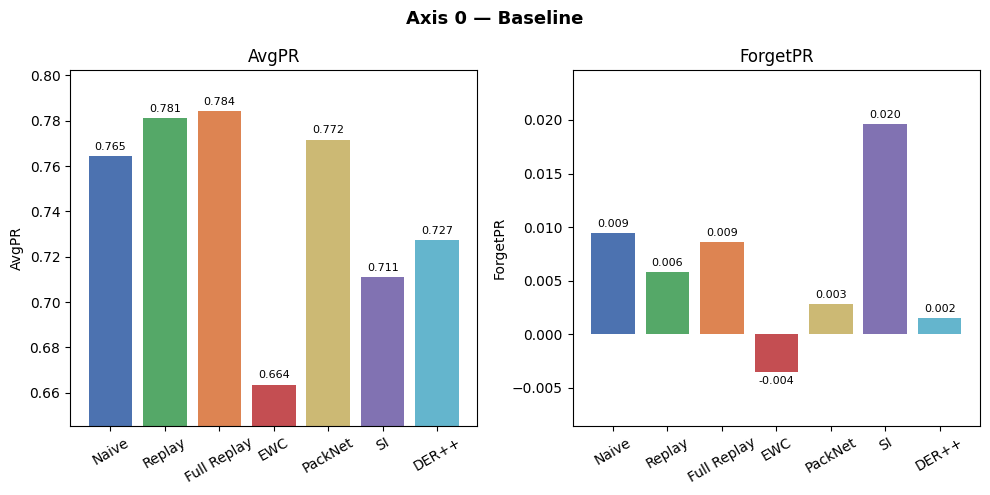

  Saved: Thesis Figures\axis1_drift_magnitude_AvgPR.png


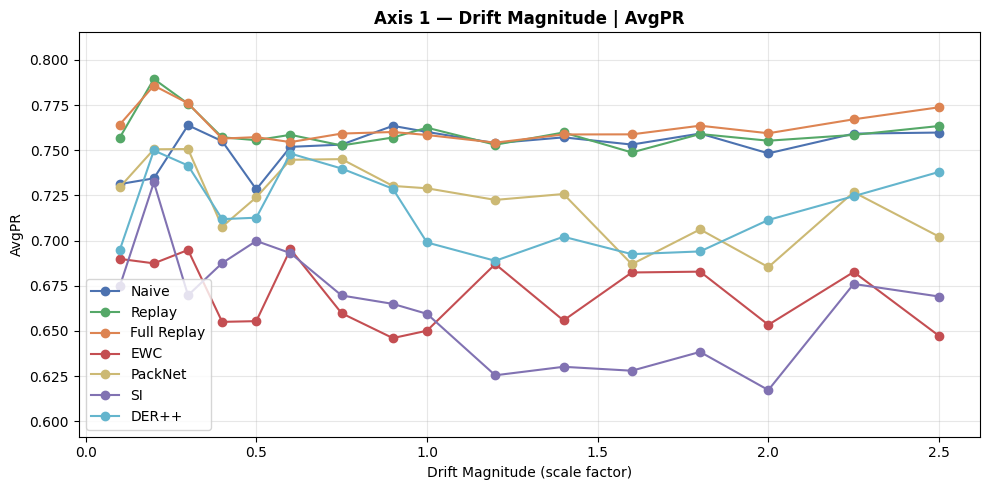

  Saved: Thesis Figures\axis1_drift_magnitude_ForgetPR.png


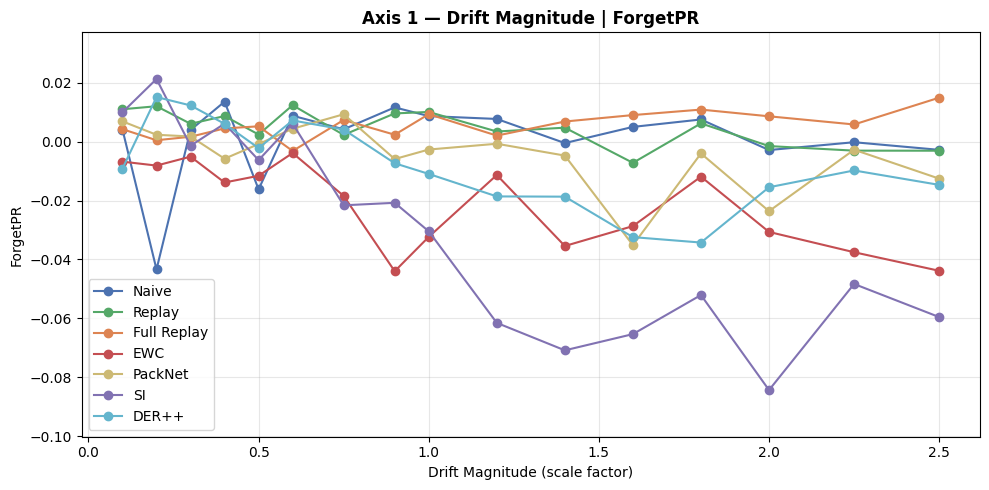

  Saved: Thesis Figures\axis2_drift_speed_AvgPR.png


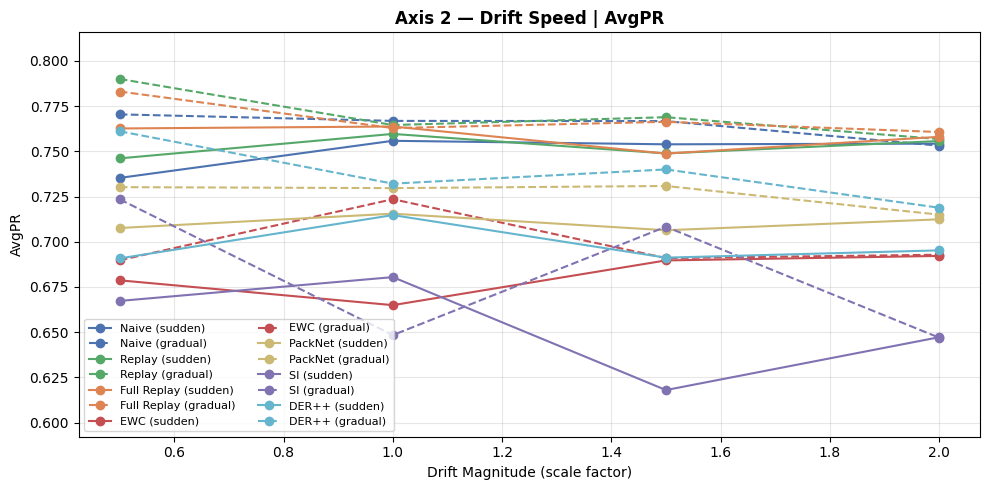

  Saved: Thesis Figures\axis2_drift_speed_ForgetPR.png


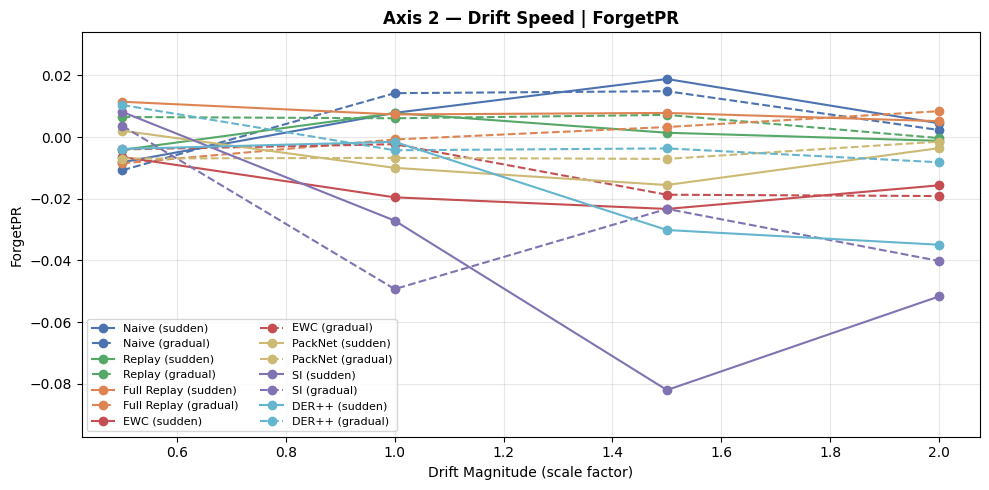

  Saved: Thesis Figures\axis3_freeze_duration_AvgPR.png


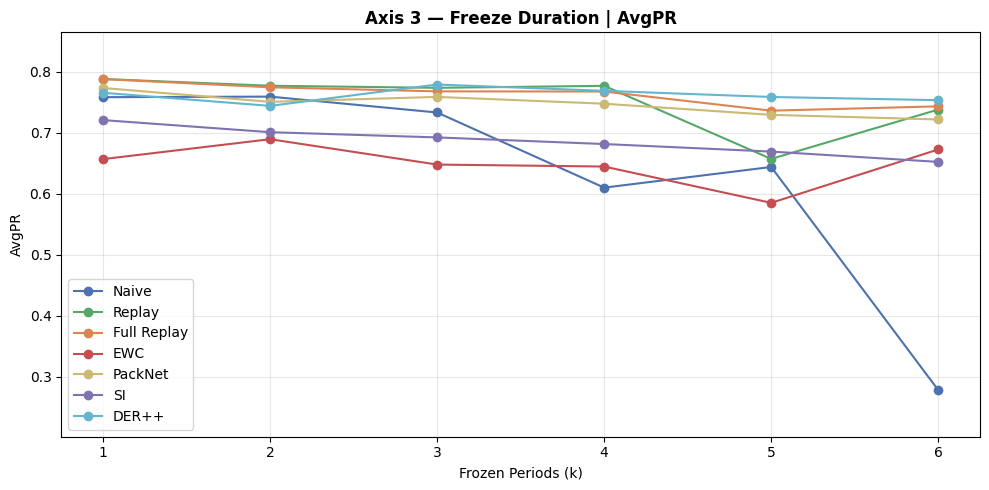

  Saved: Thesis Figures\axis3_freeze_duration_ForgetPR.png


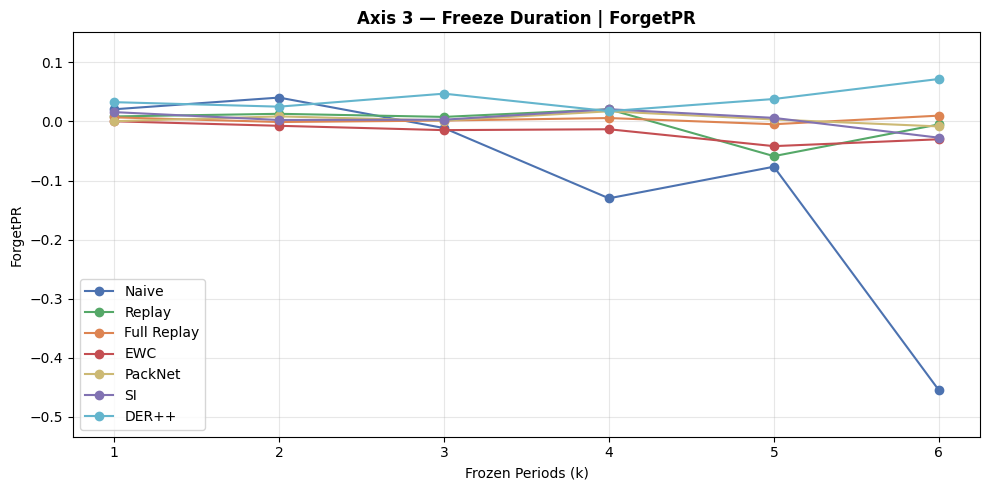

  Saved: Thesis Figures\axis4_freeze_depth_AvgPR.png


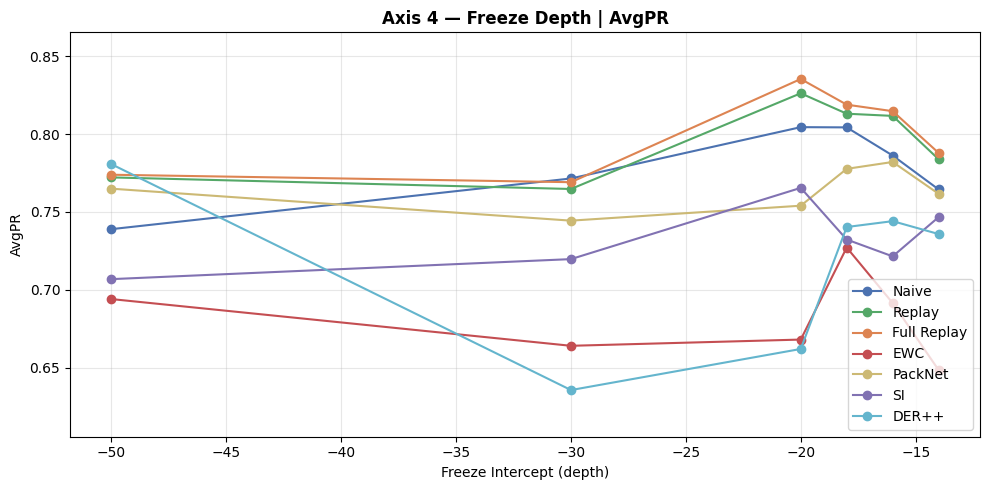

  Saved: Thesis Figures\axis4_freeze_depth_ForgetPR.png


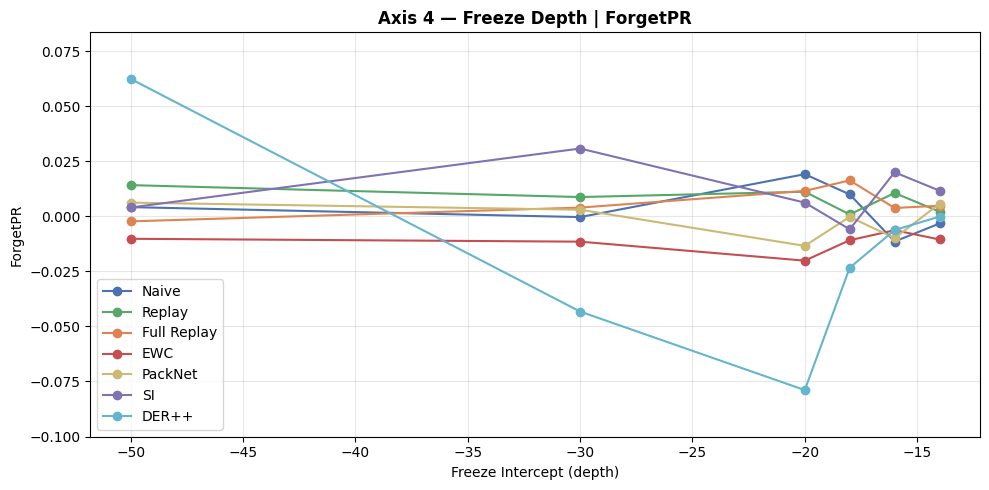

  Saved: Thesis Figures\axis5_pattern_rotation_AvgPR.png


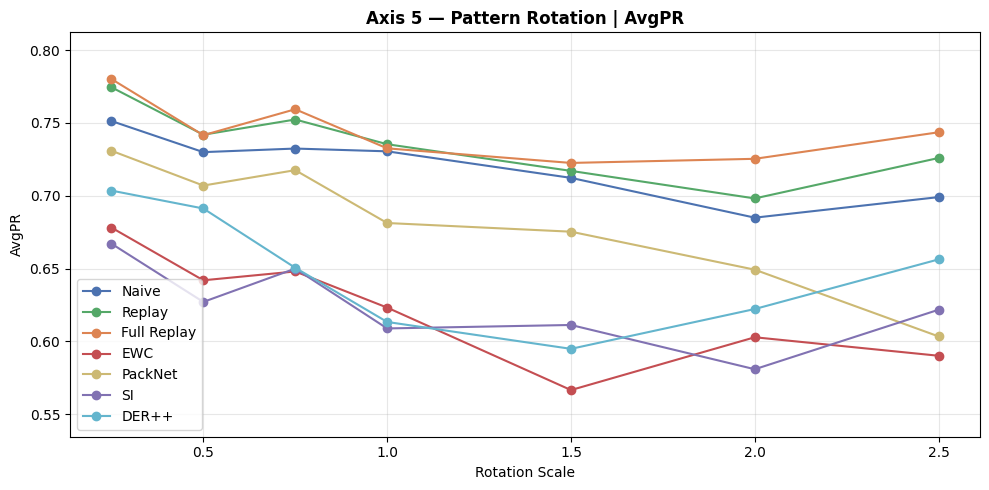

  Saved: Thesis Figures\axis5_pattern_rotation_ForgetPR.png


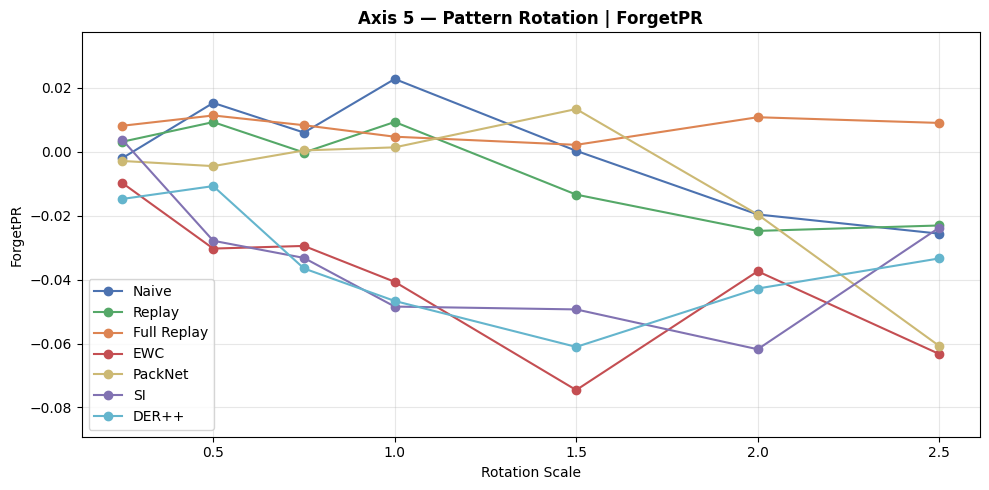


All per-axis figures generated.


In [19]:
# --- PER-AXIS VISUALIZATIONS FROM SAVED RESULTS ---
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Method styling — add/reorder here; only methods with results get plotted
METHOD_STYLE = {
    "naive":       {"color": "#4C72B0", "label": "Naive"},
    "replay":      {"color": "#55A868", "label": "Replay"},
    "full_replay": {"color": "#DD8452", "label": "Full Replay"},
    "ewc":         {"color": "#C44E52", "label": "EWC"},
    "packnet":     {"color": "#CCB974", "label": "PackNet"},
    "si":          {"color": "#8172B2", "label": "SI"},
    "der":         {"color": "#64B5CD", "label": "DER++"},
}

RESULTS_DIR = Path("experiment_results")
FIGURES_DIR = Path("Thesis Figures")
FIGURES_DIR.mkdir(exist_ok=True)

if not RESULTS_DIR.exists() or not any(RESULTS_DIR.iterdir()):
    print("No results found in experiment_results/ — run the training cell first.")
else:
    ds_results = {}
    for ds_dir in sorted(RESULTS_DIR.iterdir()):
        if not ds_dir.is_dir():
            continue
        acc_methods = {f.stem.replace("_acc", "") for f in ds_dir.glob("*_acc.npy")}
        pr_methods  = {f.stem.replace("_pr",  "") for f in ds_dir.glob("*_pr.npy")}
        methods = sorted(acc_methods & pr_methods)
        if not methods:
            continue
        ds_results[ds_dir.name] = {
            m: (np.load(ds_dir / f"{m}_acc.npy"), np.load(ds_dir / f"{m}_pr.npy"))
            for m in methods
        }

    # Group datasets by axis using the existing DATASETS dict
    axis_groups = {}
    for ds_name, info in DATASETS.items():
        if ds_name not in ds_results:
            continue
        ax = info["axis"]
        if ax not in axis_groups:
            axis_groups[ax] = []
        axis_groups[ax].append((ds_name, info, ds_results[ds_name]))

    if not axis_groups:
        print("Results folder exists but no dataset names matched DATASETS.")

    def _axis_methods(entries):
        # Return methods ordered by METHOD_STYLE that are present in at least one dataset
        present = set()
        for _, _, mdict in entries:
            present |= mdict.keys()
        return [m for m in METHOD_STYLE if m in present]

    def _save(fig, name):
        path = FIGURES_DIR / name
        fig.savefig(path, bbox_inches="tight", dpi=150)
        print(f"  Saved: {path}")

    def _auto_ylim(ax, pad_frac=0.15, min_pad=0.005):
        """Set y-axis to actual data range + small margin instead of fixed 0-1."""
        ydata = []
        for line in ax.get_lines():
            ydata.extend([float(v) for v in line.get_ydata() if not (v != v)])  # skip NaN
        for patch in ax.patches:
            h = patch.get_height()
            if h == h:  # not NaN
                ydata.append(h)
        if not ydata:
            return
        ymin, ymax = min(ydata), max(ydata)
        span = ymax - ymin
        pad = max(span * pad_frac, min_pad)
        ax.set_ylim(ymin - pad, ymax + pad)

    METRICS = [("AvgPR", 2), ("ForgetPR", 3)]  # (label, index in compute_thesis_metrics tuple)

    # ── AXIS 0: Baseline — bar chart ─────────────────────────────────────────
    if 0 in axis_groups:
        entries = axis_groups[0]
        methods = _axis_methods(entries)
        _, _, mdict = entries[0]  # only 1 dataset
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        fig.suptitle("Axis 0 — Baseline", fontsize=13, fontweight="bold")
        for ax, (metric_label, midx) in zip(axes, METRICS):
            labels, vals, colors = [], [], []
            for m in methods:
                if m not in mdict:
                    continue
                met = compute_thesis_metrics(*mdict[m])
                labels.append(METHOD_STYLE.get(m, {}).get("label", m))
                vals.append(met[midx])
                colors.append(METHOD_STYLE.get(m, {}).get("color", "gray"))
            bars = ax.bar(labels, vals, color=colors)
            ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=3)
            ax.set_title(metric_label)
            ax.set_ylabel(metric_label)
            _auto_ylim(ax)
            ax.tick_params(axis="x", rotation=30)
        plt.tight_layout()
        _save(fig, "axis0_baseline.png")
        plt.show()

    # ── AXIS 1: Drift Magnitude — line plot (x = scale) ──────────────────────
    if 1 in axis_groups:
        entries = sorted(axis_groups[1], key=lambda t: t[1]["scale"])
        methods = _axis_methods(entries)
        for metric_label, midx in METRICS:
            fig, ax = plt.subplots(figsize=(10, 5))
            ax.set_title(f"Axis 1 — Drift Magnitude | {metric_label}", fontweight="bold")
            for m in methods:
                xs, ys = [], []
                for ds_name, info, mdict in entries:
                    if m not in mdict:
                        continue
                    xs.append(info["scale"])
                    ys.append(compute_thesis_metrics(*mdict[m])[midx])
                if xs:
                    style = METHOD_STYLE.get(m, {})
                    ax.plot(xs, ys, marker="o", color=style.get("color"),
                            label=style.get("label", m))
            ax.set_xlabel("Drift Magnitude (scale factor)")
            ax.set_ylabel(metric_label)
            _auto_ylim(ax)
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            _save(fig, f"axis1_drift_magnitude_{metric_label}.png")
            plt.show()

    # ── AXIS 2: Drift Speed — line plot (solid=sudden, dashed=gradual) ───────
    if 2 in axis_groups:
        entries = axis_groups[2]
        methods = _axis_methods(entries)
        for metric_label, midx in METRICS:
            fig, ax = plt.subplots(figsize=(10, 5))
            ax.set_title(f"Axis 2 — Drift Speed | {metric_label}", fontweight="bold")
            for m in methods:
                for drift_type, ls in [("sudden", "-"), ("gradual", "--")]:
                    xs, ys = [], []
                    for ds_name, info, mdict in sorted(entries, key=lambda t: t[1]["scale"]):
                        if info.get("type") != drift_type or m not in mdict:
                            continue
                        xs.append(info["scale"])
                        ys.append(compute_thesis_metrics(*mdict[m])[midx])
                    if xs:
                        style = METHOD_STYLE.get(m, {})
                        ax.plot(xs, ys, linestyle=ls, marker='o', color=style.get('color'),
                                label=f"{style.get('label', m)} ({drift_type})")
            ax.set_xlabel("Drift Magnitude (scale factor)")
            ax.set_ylabel(metric_label)
            _auto_ylim(ax)
            ax.legend(fontsize=8, ncol=2)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            _save(fig, f"axis2_drift_speed_{metric_label}.png")
            plt.show()

    # ── AXIS 3: Freeze Duration — line plot (x = k) ───────────────────────────
    if 3 in axis_groups:
        entries = sorted(axis_groups[3], key=lambda t: t[1]["k"])
        methods = _axis_methods(entries)
        for metric_label, midx in METRICS:
            fig, ax = plt.subplots(figsize=(10, 5))
            ax.set_title(f"Axis 3 — Freeze Duration | {metric_label}", fontweight="bold")
            for m in methods:
                xs, ys = [], []
                for ds_name, info, mdict in entries:
                    if m not in mdict:
                        continue
                    xs.append(info["k"])
                    ys.append(compute_thesis_metrics(*mdict[m])[midx])
                if xs:
                    style = METHOD_STYLE.get(m, {})
                    ax.plot(xs, ys, marker="o", color=style.get("color"),
                            label=style.get("label", m))
            ax.set_xlabel("Frozen Periods (k)")
            ax.set_ylabel(metric_label)
            _auto_ylim(ax)
            ax.set_xticks(sorted({t[1]["k"] for t in entries}))
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            _save(fig, f"axis3_freeze_duration_{metric_label}.png")
            plt.show()

    # ── AXIS 4: Freeze Depth — line plot (x = depth) ─────────────────────────
    if 4 in axis_groups:
        entries = sorted(axis_groups[4], key=lambda t: t[1]["depth"])
        methods = _axis_methods(entries)
        for metric_label, midx in METRICS:
            fig, ax = plt.subplots(figsize=(10, 5))
            ax.set_title(f"Axis 4 — Freeze Depth | {metric_label}", fontweight="bold")
            for m in methods:
                xs, ys = [], []
                for ds_name, info, mdict in entries:
                    if m not in mdict:
                        continue
                    xs.append(info["depth"])
                    ys.append(compute_thesis_metrics(*mdict[m])[midx])
                if xs:
                    style = METHOD_STYLE.get(m, {})
                    ax.plot(xs, ys, marker="o", color=style.get("color"),
                            label=style.get("label", m))
            ax.set_xlabel("Freeze Intercept (depth)")
            ax.set_ylabel(metric_label)
            _auto_ylim(ax)
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            _save(fig, f"axis4_freeze_depth_{metric_label}.png")
            plt.show()

    # ── AXIS 5: Pattern Rotation — line plot (x = scale) ─────────────────────
    if 5 in axis_groups:
        entries = sorted(axis_groups[5], key=lambda t: t[1]["scale"])
        methods = _axis_methods(entries)
        for metric_label, midx in METRICS:
            fig, ax = plt.subplots(figsize=(10, 5))
            ax.set_title(f"Axis 5 — Pattern Rotation | {metric_label}", fontweight="bold")
            for m in methods:
                xs, ys = [], []
                for ds_name, info, mdict in entries:
                    if m not in mdict:
                        continue
                    xs.append(info["scale"])
                    ys.append(compute_thesis_metrics(*mdict[m])[midx])
                if xs:
                    style = METHOD_STYLE.get(m, {})
                    ax.plot(xs, ys, marker="o", color=style.get("color"),
                            label=style.get("label", m))
            ax.set_xlabel("Rotation Scale")
            ax.set_ylabel(metric_label)
            _auto_ylim(ax)
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            _save(fig, f"axis5_pattern_rotation_{metric_label}.png")
            plt.show()

    print("\nAll per-axis figures generated.")


### Cross-Dataset Heatmap Per Axis

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

AXIS_CONFIG = {
    1: {"title": "Drift Magnitude",    "sort_key": lambda t: t[1]["scale"],           "x_label": "Drift Magnitude (scale)"},
    2: {"title": "Drift Speed",         "sort_key": lambda t: (t[1]["type"], t[1]["scale"]), "x_label": "Drift Type x Scale"},
    3: {"title": "Freeze Duration",     "sort_key": lambda t: t[1]["k"],               "x_label": "Frozen Periods (k)"},
    4: {"title": "Freeze Depth",        "sort_key": lambda t: t[1]["depth"],            "x_label": "Freeze Depth"},
    5: {"title": "Pattern Rotation",    "sort_key": lambda t: t[1]["scale"],            "x_label": "Rotation Scale"},
}

for ax_idx, cfg in AXIS_CONFIG.items():
    if ax_idx not in axis_groups:
        continue

    entries = sorted(axis_groups[ax_idx], key=cfg["sort_key"])
    methods = _axis_methods(entries)
    method_labels = [METHOD_STYLE[m]["label"] for m in methods]
    x_labels = [info["label"] for _, info, _ in entries]

    for metric_label, midx in METRICS:
        # Build matrix: rows = methods, cols = datasets
        mat = np.full((len(methods), len(entries)), np.nan)
        for ci, (_, _, mdict) in enumerate(entries):
            for ri, m in enumerate(methods):
                if m in mdict:
                    mat[ri, ci] = compute_thesis_metrics(*mdict[m])[midx]

        vmin, vmax = np.nanmin(mat), np.nanmax(mat)

        # For ForgetPR use diverging colormap centered at 0
        if metric_label == "ForgetPR":
            abs_max = max(abs(vmin), abs(vmax))
            vmin_plot, vmax_plot = -abs_max, abs_max
            cmap = "RdYlGn"
        else:
            vmin_plot, vmax_plot = vmin, vmax
            cmap = "RdYlGn"

        fig_w = max(8, len(x_labels) * 1.0)
        fig_h = max(3, len(methods) * 0.65)
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        ax.set_title(f"Axis {ax_idx} — {cfg['title']} | {metric_label}", fontweight="bold")

        im = ax.imshow(mat, cmap=cmap, vmin=vmin_plot, vmax=vmax_plot, aspect="auto")

        for ri in range(len(methods)):
            for ci in range(len(x_labels)):
                val = mat[ri, ci]
                if not np.isnan(val):
                    norm_val = (val - vmin_plot) / (vmax_plot - vmin_plot) if vmax_plot != vmin_plot else 0.5
                    txt_col = "black" if 0.25 < norm_val < 0.75 else "white"
                    ax.text(ci, ri, f"{val:.3f}", ha="center", va="center",
                            fontsize=8, fontweight="bold", color=txt_col)

        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels, fontsize=8, rotation=30, ha="right")
        ax.set_yticks(range(len(methods)))
        ax.set_yticklabels(method_labels, fontsize=10)
        ax.set_xlabel(cfg["x_label"])
        plt.colorbar(im, ax=ax, label=metric_label, fraction=0.03, pad=0.04)
        plt.tight_layout()
        _save(fig, f"axis{ax_idx}_heatmap_{metric_label}.png")
        plt.show()

print("All per-axis heatmaps generated.")

### PR-AUC Heatmap: Baseline dataset x Naive method

  Saved: Thesis Figures\baseline_naive_pr_heatmap.png


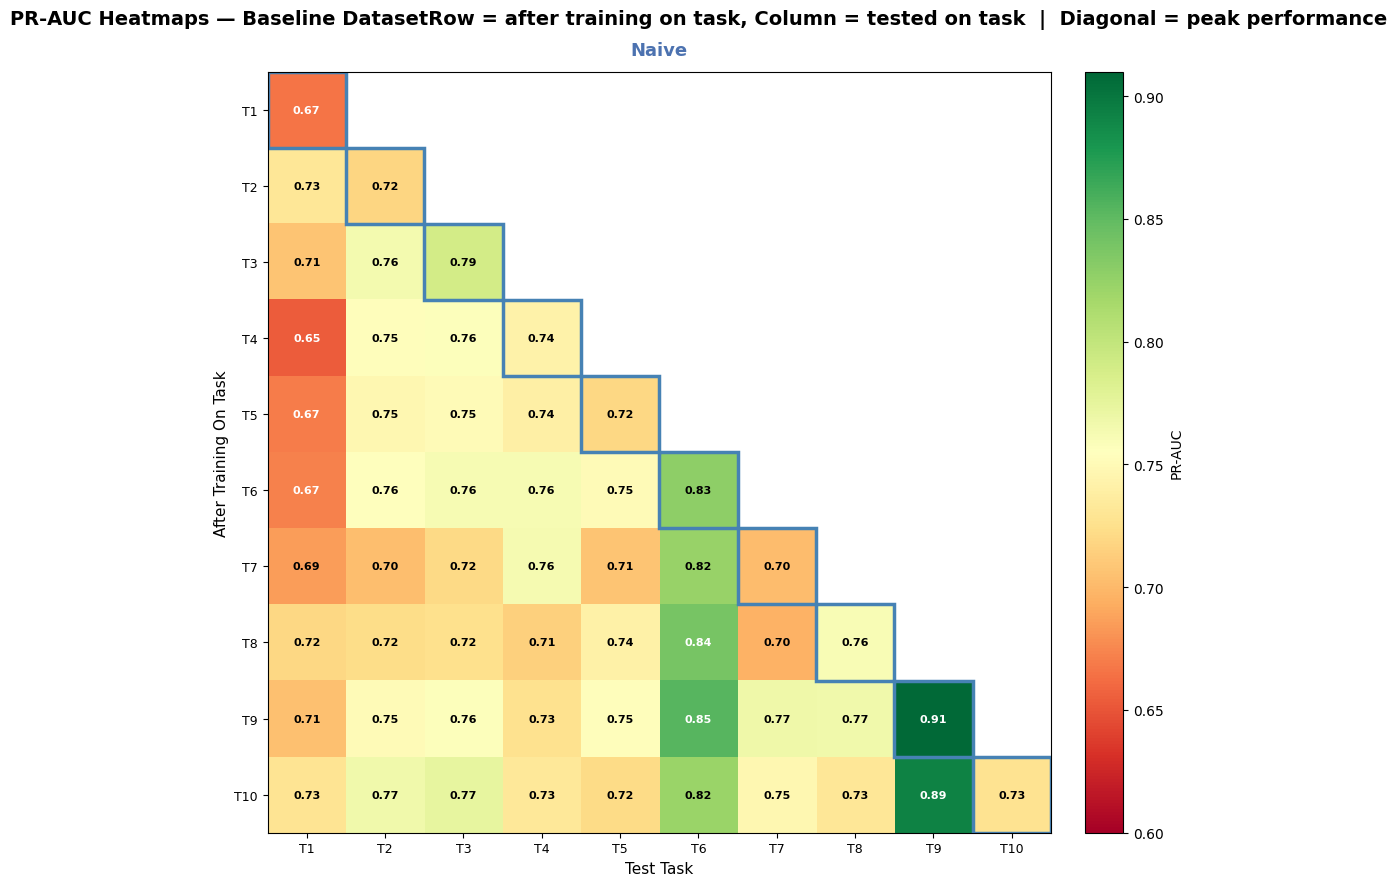

In [21]:
import matplotlib.pyplot as plt
import numpy as np

ds_name = "drift_baseline"
method  = "naive"

if ds_name not in ds_results or method not in ds_results[ds_name]:
    print(f"No results found for {ds_name} / {method}. Run the training cell first.")
else:
    _, pr_mat = ds_results[ds_name][method]
    n = pr_mat.shape[0]
    task_labels = [f"T{t}" for t in range(1, n + 1)]

    masked = np.where(pr_mat == 0, np.nan, pr_mat)
    vmin_plot = np.floor(np.nanmin(masked) / 0.12) * 0.12
    vmax_plot = np.ceil(np.nanmax(masked)  / 0.07) * 0.07

    fig, ax = plt.subplots(figsize=(10, 9))
    fig.suptitle(
        "PR-AUC Heatmaps — Baseline Dataset"
        "Row = after training on task, Column = tested on task  |  Diagonal = peak performance",
        fontsize=14, fontweight="bold",
    )
    ax.set_title("Naive", fontsize=13, fontweight="bold", color="#4C72B0", pad=12)

    im = ax.imshow(masked, vmin=vmin_plot, vmax=vmax_plot, cmap="RdYlGn", aspect="auto")

    for row in range(n):
        for col in range(n):
            val = pr_mat[row, col]
            if val > 0:
                norm_val = (val - vmin_plot) / (vmax_plot - vmin_plot) if vmax_plot != vmin_plot else 0.5
                txt_color = "black" if 0.25 < norm_val < 0.75 else "white"
                ax.text(col, row, f"{val:.2f}", ha="center", va="center",
                        fontsize=8, color=txt_color, fontweight="bold")

    for t in range(n):
        ax.add_patch(plt.Rectangle(
            (t - 0.5, t - 0.5), 1, 1,
            fill=False, edgecolor="steelblue", linewidth=2.5,
        ))

    ax.set_xlabel("Test Task", fontsize=11)
    ax.set_ylabel("After Training On Task", fontsize=11)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(task_labels, fontsize=9)
    ax.set_yticklabels(task_labels, fontsize=9)
    plt.colorbar(im, ax=ax, label="PR-AUC", fraction=0.046, pad=0.04)
    plt.tight_layout()
    _save(fig, "baseline_naive_pr_heatmap.png")
    plt.show()
